# 04 — Exploratory Data Analysis (EDA)

## Purpose

This notebook explores the official analysis-ready dataset before applying
sentiment analysis or topic modeling.

It answers the following questions:

1. Is the processed dataset valid?
2. How are records distributed across platforms and sources?
3. How long are the texts?
4. Which AI tools are mentioned most often?
5. Which predefined research themes appear most often?
6. How does the volume of discussions evolve over time?
7. How do tools and themes differ across platforms?
8. What limitations must be considered before modeling?




## 1. Imports and project paths

The following cell:

- imports the required libraries;
- locates the project root automatically;
- defines the input, figure, and result folders.


In [104]:
from pathlib import Path
import ast
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")


def find_project_root(start: Path | None = None) -> Path:
    """Find the project folder containing data/processed."""
    current = (start or Path.cwd()).resolve()

    candidates = [current, *current.parents]

    for candidate in candidates:
        if (candidate / "data" / "processed").exists():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Run this notebook from the project folder "
        "or from the notebooks folder."
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "analysis_ready_posts.jsonl"
FIGURE_DIR = PROJECT_ROOT / "figures" / "eda"
RESULTS_DIR = PROJECT_ROOT / "data" / "results" / "eda"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())
print("Figures folder:", FIGURE_DIR)
print("Results folder:", RESULTS_DIR)


Project root: /home/rei/Desktop/internship/AI-Developer-Sentiment
Dataset: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/processed/analysis_ready_posts.jsonl
Dataset exists: True
Figures folder: /home/rei/Desktop/internship/AI-Developer-Sentiment/figures/eda
Results folder: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/eda


## 2. Load the processed dataset

The EDA uses the processed file:

`data/processed/analysis_ready_posts.jsonl`

The raw dataset is not used here.


In [73]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Confirm that the cleaning phase created analysis_ready_posts.jsonl."
    )

df = pd.read_json(DATA_PATH, lines=True)

print(f"Loaded records: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")

display(df.head(5))


Loaded records: 2,666
Number of columns: 48


,record_id,source_id,source,platform,community,created_at_utc,date_known,is_recent_2025_plus,title_raw,body_raw,...,created_utc,created_iso,text,likes,replies_count,quotes_count,reblogs_count,relevant,is_ai_relevant,text_hash
0,huggingface_uit-sentiment-dataset-reddit-2000-...,1kby1en,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LocalLLaMA,2025-05-01T02:22:03+00:00,True,True,,Shuttle-3.5 (Qwen3 32b Finetune) We are excite...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,1d9ae9c76d041d305769df63eab8285c1388bd41ddb381...
1,huggingface_uit-sentiment-dataset-reddit-2000-...,1kbym1e,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,OpenAI,2025-05-01T02:52:48+00:00,True,True,,current llms still suck I am using the top mod...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,29a4834457d0d17c5a1c242f7e37fef03445e3bf3d6e70...
2,huggingface_uit-sentiment-dataset-reddit-2000-...,1kchgyo,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LocalLLaMA,2025-05-01T19:33:44+00:00,True,True,,Anthropic claims chips are smuggled as prosthe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,9e6603632ea5d670404a9ecd536533f03bf059a3eee592...
3,huggingface_uit-sentiment-dataset-reddit-2000-...,1kd9kcf,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,singularity,2025-05-02T19:28:21+00:00,True,True,,"I don't know why but being called a ""Human"" by...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,60aae8494f66a3f27106f6ec44345e33c16342fd2e2208...
4,huggingface_uit-sentiment-dataset-reddit-2000-...,1kdqcjk,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LocalLLaMA,2025-05-03T11:00:49+00:00,True,True,,Teaching LLMs to use tools with RL! Successful...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,3b7bb80042691fdd0933eba2ebad82d30ddc6c5ba2b2c0...


## 3. Verify the required columns

This step confirms that the cleaned dataset contains the fields required for
the EDA.

The notebook stops only when an essential column is missing.


In [74]:
required_columns = [
    "record_id",
    "source",
    "platform",
    "full_text_raw",
    "text_clean_basic",
    "text_clean_lexical",
    "ai_tools",
    "research_themes",
    "word_count",
]

optional_columns = [
    "community",
    "created_at_utc",
    "date_known",
    "text_length_chars",
    "score",
    "num_comments",
    "analysis_eligible",
    "is_exact_text_duplicate",
]

missing_required = [
    column for column in required_columns
    if column not in df.columns
]

missing_optional = [
    column for column in optional_columns
    if column not in df.columns
]

print("Missing required columns:", missing_required)
print("Missing optional columns:", missing_optional)

if missing_required:
    raise ValueError(
        "The processed dataset is missing required columns: "
        + ", ".join(missing_required)
    )


Missing required columns: []
Missing optional columns: []


## 4. Normalize list columns and dates

The fields `ai_tools` and `research_themes` should contain Python lists.

This cell makes the notebook robust in case a list was saved as a string.

It also converts the date field to a pandas datetime.


In [75]:
def ensure_list(value):
    """Convert a saved list-like value into a Python list."""
    if isinstance(value, list):
        return value

    if value is None:
        return []

    try:
        if pd.isna(value):
            return []
    except (TypeError, ValueError):
        pass

    if isinstance(value, str):
        stripped = value.strip()

        if not stripped or stripped.lower() in {"nan", "none", "null", "[]"}:
            return []

        try:
            parsed = ast.literal_eval(stripped)
            if isinstance(parsed, list):
                return parsed
        except (ValueError, SyntaxError):
            pass

        return [stripped]

    return [value]


df["ai_tools"] = df["ai_tools"].map(ensure_list)
df["research_themes"] = df["research_themes"].map(ensure_list)

if "created_at_utc" in df.columns:
    df["created_at_utc"] = pd.to_datetime(
        df["created_at_utc"],
        errors="coerce",
        utc=True,
    )
else:
    df["created_at_utc"] = pd.NaT

if "date_known" not in df.columns:
    df["date_known"] = df["created_at_utc"].notna()
else:
    df["date_known"] = df["created_at_utc"].notna()

if "text_length_chars" not in df.columns:
    df["text_length_chars"] = (
        df["text_clean_basic"]
        .fillna("")
        .astype(str)
        .str.len()
    )

print("List and date columns are ready.")


List and date columns are ready.


## 5. Final data-quality validation

This is a safety check before creating charts.

Expected results:

- no missing record IDs;
- no duplicate record IDs;
- no empty analysis text;
- minimum word count of at least five;
- no exact duplicates in the final dataset.


In [76]:
validation_results = {
    "records": len(df),
    "missing_record_ids": int(df["record_id"].isna().sum()),
    "duplicate_record_ids": int(df["record_id"].duplicated().sum()),
    "empty_basic_texts": int(
        df["text_clean_basic"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    ),
    "minimum_word_count": int(df["word_count"].min()),
    "missing_dates": int(df["created_at_utc"].isna().sum()),
}

if "is_exact_text_duplicate" in df.columns:
    validation_results["remaining_exact_duplicates"] = int(
        df["is_exact_text_duplicate"].fillna(False).sum()
    )

if "analysis_eligible" in df.columns:
    validation_results["ineligible_rows_in_final_data"] = int(
        (~df["analysis_eligible"].fillna(False)).sum()
    )

validation_table = (
    pd.Series(validation_results, name="value")
    .rename_axis("check")
    .reset_index()
)

display(validation_table)

validation_table.to_csv(
    RESULTS_DIR / "validation_summary.csv",
    index=False,
)


,check,value
0,records,2666
1,missing_record_ids,0
2,duplicate_record_ids,0
3,empty_basic_texts,0
4,minimum_word_count,5
5,missing_dates,139
6,remaining_exact_duplicates,0
7,ineligible_rows_in_final_data,0


### Validation interpretation

A non-zero value for duplicate IDs, empty texts, remaining exact duplicates,
or ineligible rows should be investigated before modeling.

Missing dates are acceptable, but those records cannot be used in temporal
analysis.


## 6. General dataset overview

This section summarizes the size, variety, date coverage, and text length of
the final dataset.


In [77]:
dated_records = int(df["created_at_utc"].notna().sum())
missing_dates = int(df["created_at_utc"].isna().sum())

overview = {
    "records": len(df),
    "columns": len(df.columns),
    "platforms": df["platform"].nunique(dropna=True),
    "sources": df["source"].nunique(dropna=True),
    "dated_records": dated_records,
    "missing_dates": missing_dates,
    "date_coverage_percent": round(dated_records / len(df) * 100, 2),
    "average_words": round(df["word_count"].mean(), 2),
    "median_words": round(df["word_count"].median(), 2),
    "minimum_words": int(df["word_count"].min()),
    "maximum_words": int(df["word_count"].max()),
}

overview_table = (
    pd.Series(overview, name="value")
    .rename_axis("metric")
    .reset_index()
)

display(overview_table)

overview_table.to_csv(
    RESULTS_DIR / "eda_overview.csv",
    index=False,
)


,metric,value
0,records,2666.00
1,columns,48.00
2,platforms,5.00
3,sources,6.00
4,dated_records,2527.00
5,missing_dates,139.00
6,date_coverage_percent,94.79
7,average_words,175.02
8,median_words,97.00
9,minimum_words,5.00


## 7. Distribution by platform

This analysis identifies whether one platform dominates the sample.

Both counts and percentages are calculated.


In [78]:
platform_counts = (
    df["platform"]
    .fillna("Unknown")
    .value_counts()
    .rename_axis("platform")
    .reset_index(name="records")
)

platform_counts["percentage"] = (
    platform_counts["records"] / len(df) * 100
).round(2)

display(platform_counts)

platform_counts.to_csv(
    RESULTS_DIR / "platform_summary.csv",
    index=False,
)


,platform,records,percentage
0,Reddit,2033,76.26
1,GitHub Issues,245,9.19
2,Hacker News,140,5.25
3,Other social dataset,139,5.21
4,Stack Overflow,109,4.09


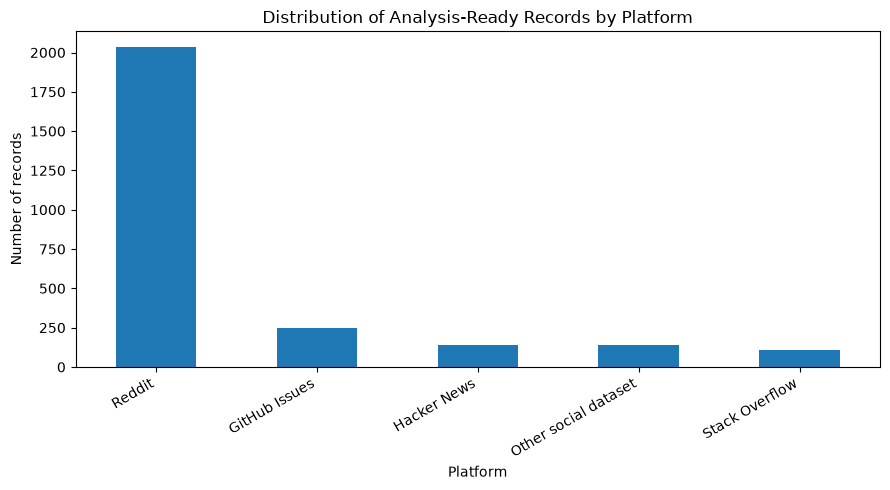

In [79]:
plt.figure(figsize=(9, 5))

plot_data = platform_counts.set_index("platform")["records"]
plot_data.plot(kind="bar")

plt.title("Distribution of Analysis-Ready Records by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of records")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "records_by_platform.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### How to interpret this chart

- The highest bar represents the most influential platform in the dataset.
- When one platform contributes most records, global results may mainly reflect
  that platform.
- Sentiment and topic results should therefore also be reported by platform.


## 8. Distribution by source

A platform may contain records from more than one collection source.

This table and chart show the exact source composition.


In [80]:
source_counts = (
    df["source"]
    .fillna("Unknown")
    .value_counts()
    .rename_axis("source")
    .reset_index(name="records")
)

source_counts["percentage"] = (
    source_counts["records"] / len(df) * 100
).round(2)

display(source_counts)

source_counts.to_csv(
    RESULTS_DIR / "source_summary.csv",
    index=False,
)


,source,records,percentage
0,huggingface_uit-sentiment-dataset-reddit-2000-...,1869,70.11
1,github_issues,245,9.19
2,arctic_shift,164,6.15
3,hackernews,140,5.25
4,huggingface_divde-sentiment_posts,139,5.21
5,stackoverflow,109,4.09


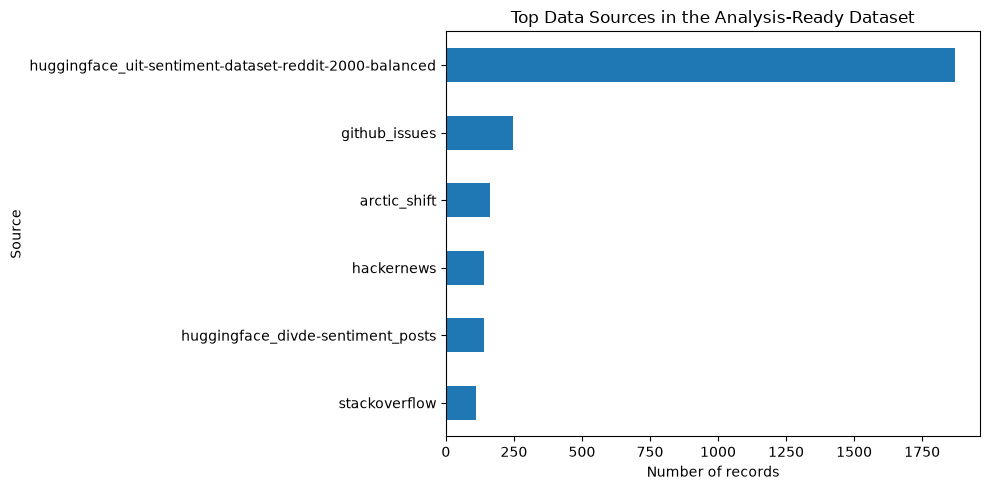

In [81]:
plt.figure(figsize=(10, 5))

source_plot = (
    source_counts
    .head(15)
    .sort_values("records")
    .set_index("source")["records"]
)

source_plot.plot(kind="barh")

plt.title("Top Data Sources in the Analysis-Ready Dataset")
plt.xlabel("Number of records")
plt.ylabel("Source")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "records_by_source.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 9. Most represented communities

The `community` field may represent a subreddit, GitHub repository, or another
source-specific group.

This section is executed only when the field exists.


In [82]:
if "community" in df.columns:
    community_counts = (
        df["community"]
        .replace("", np.nan)
        .dropna()
        .value_counts()
        .head(20)
        .rename_axis("community")
        .reset_index(name="records")
    )

    display(community_counts)

    community_counts.to_csv(
        RESULTS_DIR / "top_communities.csv",
        index=False,
    )
else:
    community_counts = pd.DataFrame()
    print("The community column is not available.")


,community,records
0,LocalLLaMA,927
1,OpenAI,412
2,singularity,366
3,artificial,164
4,hackernews,140
5,github/microsoft/vscode,136
6,stackoverflow,109
7,github/huggingface/transformers,58
8,cscareerquestions,52
9,MachineLearning,45


## 10. Text-length statistics

The mean can be affected by a few extremely long texts.

The median usually represents the typical text more reliably when the
distribution is skewed.


In [83]:
text_length_summary = (
    df[["text_length_chars", "word_count"]]
    .describe()
    .round(2)
)

display(text_length_summary)

text_length_summary.to_csv(
    RESULTS_DIR / "text_length_summary.csv"
)


,text_length_chars,word_count
count,2666.00,2666.00
mean,1074.14,175.02
std,1677.68,254.11
min,15.00,5.00
25%,174.00,30.00
50%,539.00,97.00
75%,1299.75,219.75
max,25924.00,3484.00


99th percentile word count: 1142.75


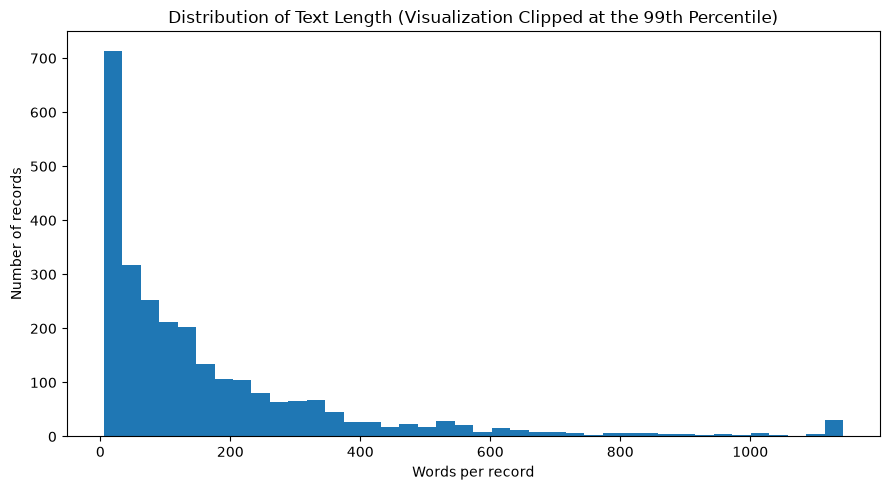

In [84]:
word_limit_99 = df["word_count"].quantile(0.99)

print(f"99th percentile word count: {word_limit_99:.2f}")

plt.figure(figsize=(9, 5))

df["word_count"].clip(upper=word_limit_99).plot(
    kind="hist",
    bins=40,
)

plt.title(
    "Distribution of Text Length "
    "(Visualization Clipped at the 99th Percentile)"
)
plt.xlabel("Words per record")
plt.ylabel("Number of records")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "text_length_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Why the histogram is clipped

Only the visualization is clipped at the 99th percentile.

No record is removed. The purpose is to prevent a few extremely long texts
from making the chart unreadable.


## 11. Text length by platform

This comparison helps identify whether certain platforms contain longer or
shorter documents.


In [85]:
length_by_platform = (
    df.groupby("platform")["word_count"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .sort_values("count", ascending=False)
)

display(length_by_platform)

length_by_platform.to_csv(
    RESULTS_DIR / "text_length_by_platform.csv"
)


,count,mean,median,min,max
platform,,,,,
Reddit,2033,153.37,92.0,5,3023
GitHub Issues,245,438.66,328.0,15,3484
Hacker News,140,71.01,13.0,5,514
Other social dataset,139,43.65,39.0,5,311
Stack Overflow,109,287.39,207.0,48,3040


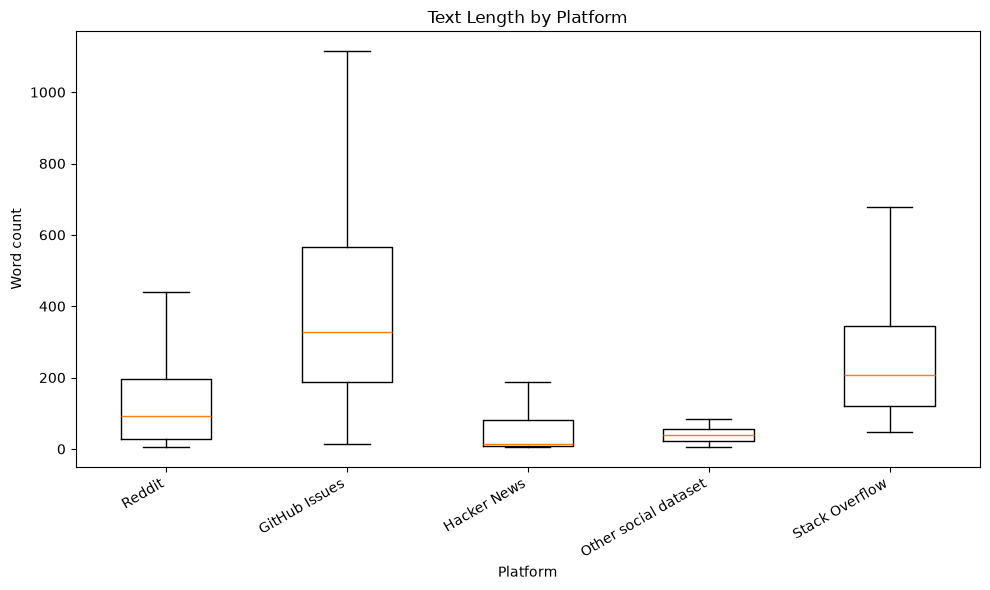

In [86]:
platform_order = (
    df["platform"]
    .value_counts()
    .index
    .tolist()
)

boxplot_data = [
    df.loc[df["platform"] == platform, "word_count"].dropna()
    for platform in platform_order
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    boxplot_data,
    showfliers=False,
)
plt.xticks(
    ticks=range(1, len(platform_order) + 1),
    labels=platform_order,
)

plt.title("Text Length by Platform")
plt.xlabel("Platform")
plt.ylabel("Word count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "text_length_by_platform.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 12. AI-tool frequencies

A record may mention more than one AI tool.

Therefore, the total number of tool occurrences can be greater than the number
of records.


In [87]:
exploded_tools = (
    df[["record_id", "platform", "ai_tools", "created_at_utc"]]
    .explode("ai_tools")
    .reset_index(drop=True)
)

exploded_tools["ai_tools"] = (
    exploded_tools["ai_tools"]
    .replace("", np.nan)
)

exploded_tools = (
    exploded_tools
    .dropna(subset=["platform", "ai_tools"])
    .copy()
)

# Normalize text labels to prevent accidental duplicate categories.
exploded_tools["platform"] = (
    exploded_tools["platform"]
    .astype(str)
    .str.strip()
)

exploded_tools["ai_tools"] = (
    exploded_tools["ai_tools"]
    .astype(str)
    .str.strip()
)

tool_counts = (
    exploded_tools["ai_tools"]
    .value_counts()
    .rename_axis("ai_tool")
    .reset_index(name="documents")
)

tool_counts["percent_of_records"] = (
    tool_counts["documents"] / len(df) * 100
).round(2)

display(tool_counts)

tool_counts.to_csv(
    RESULTS_DIR / "ai_tool_counts.csv",
    index=False,
)


,ai_tool,documents,percent_of_records
0,AI,1063,39.87
1,Claude/Anthropic,661,24.79
2,Gemini,495,18.57
3,LLM,449,16.84
4,Llama,419,15.72
5,OpenAI,255,9.56
6,ChatGPT,247,9.26
7,GPT,235,8.81
8,GitHub Copilot,155,5.81
9,AI agent,153,5.74


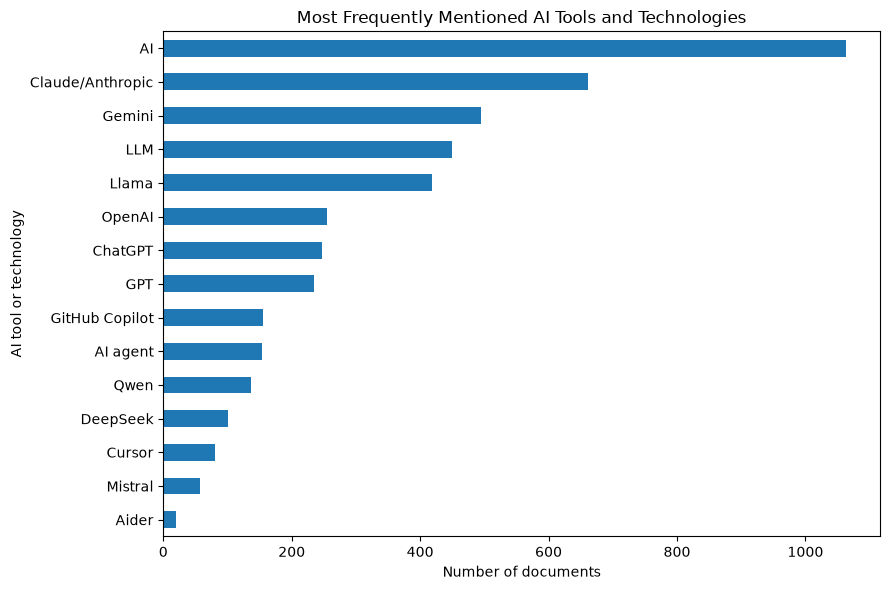

In [88]:
top_tool_plot = (
    tool_counts
    .head(15)
    .sort_values("documents")
    .set_index("ai_tool")["documents"]
)

plt.figure(figsize=(9, 6))

top_tool_plot.plot(kind="barh")

plt.title("Most Frequently Mentioned AI Tools and Technologies")
plt.xlabel("Number of documents")
plt.ylabel("AI tool or technology")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "ai_tool_frequencies.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Interpretation reminder

The percentages are not mutually exclusive because one document may mention
several tools.

This section describes representation in the corpus; it does not measure
positive or negative opinion.


## 13. Research-theme frequencies

These themes were detected using transparent keyword rules during
preprocessing.

They indicate what is being discussed, not whether the discussion is positive
or negative.


In [89]:
exploded_themes = (
    df[["record_id", "platform", "research_themes", "created_at_utc"]]
    .explode("research_themes")
    .reset_index(drop=True)
)

exploded_themes["research_themes"] = (
    exploded_themes["research_themes"]
    .replace("", np.nan)
)

exploded_themes = (
    exploded_themes
    .dropna(subset=["platform", "research_themes"])
    .copy()
)

exploded_themes["platform"] = (
    exploded_themes["platform"]
    .astype(str)
    .str.strip()
)

exploded_themes["research_themes"] = (
    exploded_themes["research_themes"]
    .astype(str)
    .str.strip()
)

theme_counts = (
    exploded_themes["research_themes"]
    .value_counts()
    .rename_axis("research_theme")
    .reset_index(name="documents")
)

theme_counts["percent_of_records"] = (
    theme_counts["documents"] / len(df) * 100
).round(2)

display(theme_counts)

theme_counts.to_csv(
    RESULTS_DIR / "research_theme_counts.csv",
    index=False,
)


,research_theme,documents,percent_of_records
0,trust_quality,433,16.24
1,job_security,110,4.13
2,privacy_security,109,4.09
3,productivity,93,3.49
4,stress_anxiety,72,2.70
5,burnout,3,0.11


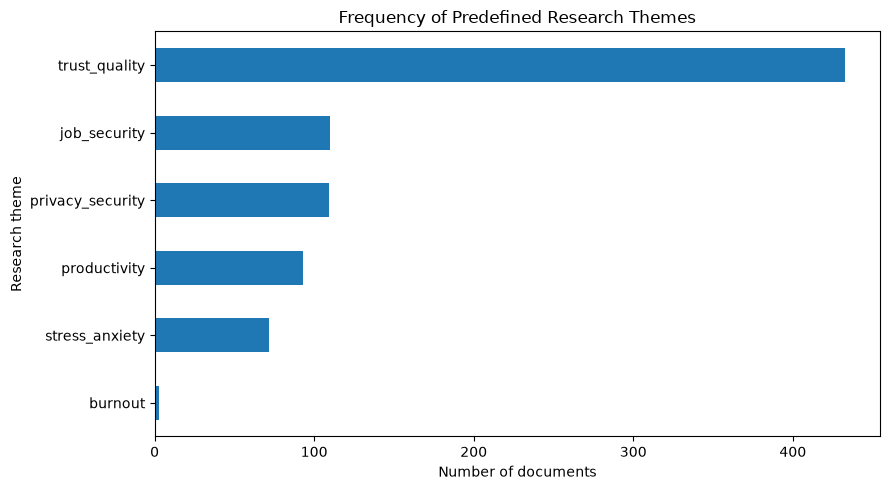

In [90]:
theme_plot = (
    theme_counts
    .sort_values("documents")
    .set_index("research_theme")["documents"]
)

plt.figure(figsize=(9, 5))

theme_plot.plot(kind="barh")

plt.title("Frequency of Predefined Research Themes")
plt.xlabel("Number of documents")
plt.ylabel("Research theme")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "research_theme_frequencies.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 14. Date coverage

This section reports the number of dated and undated records.

Only dated records are used for timeline charts.


In [91]:
date_summary = pd.DataFrame({
    "status": ["Known date", "Missing date"],
    "records": [
        int(df["created_at_utc"].notna().sum()),
        int(df["created_at_utc"].isna().sum()),
    ],
})

date_summary["percentage"] = (
    date_summary["records"] / len(df) * 100
).round(2)

display(date_summary)

date_summary.to_csv(
    RESULTS_DIR / "date_coverage.csv",
    index=False,
)

dated_df = df.dropna(subset=["created_at_utc"]).copy()

if not dated_df.empty:
    print("Earliest date:", dated_df["created_at_utc"].min())
    print("Latest date:", dated_df["created_at_utc"].max())


,status,records,percentage
0,Known date,2527,94.79
1,Missing date,139,5.21


Earliest date: 2017-07-05 11:01:18+00:00
Latest date: 2026-07-22 00:25:20+00:00


## 15. Records over time

Monthly counts show the temporal coverage of the sample.

A peak may reflect a real event, but it may also result from the data
collection method. EDA identifies the pattern without claiming its cause.


,created_at_utc,records
97,2025-08-31 00:00:00+00:00,418
98,2025-09-30 00:00:00+00:00,295
99,2025-10-31 00:00:00+00:00,212
100,2025-11-30 00:00:00+00:00,2
101,2025-12-31 00:00:00+00:00,6
102,2026-01-31 00:00:00+00:00,5
103,2026-02-28 00:00:00+00:00,5
104,2026-03-31 00:00:00+00:00,11
105,2026-04-30 00:00:00+00:00,9
106,2026-05-31 00:00:00+00:00,42


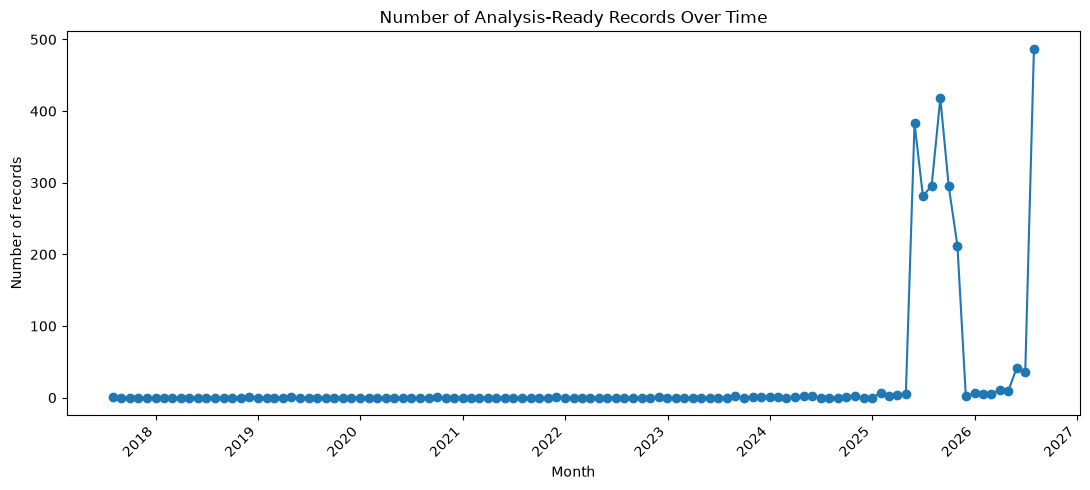

In [92]:
if dated_df.empty:
    monthly_counts = pd.DataFrame()
    print("No dated records are available.")
else:
    monthly_counts = (
        dated_df
        .set_index("created_at_utc")
        .resample("ME")
        .size()
        .rename("records")
        .reset_index()
    )

    display(monthly_counts.tail(12))

    monthly_counts.to_csv(
        RESULTS_DIR / "monthly_record_counts.csv",
        index=False,
    )

    plt.figure(figsize=(11, 5))

    plt.plot(
        monthly_counts["created_at_utc"],
        monthly_counts["records"],
        marker="o",
    )

    plt.title("Number of Analysis-Ready Records Over Time")
    plt.xlabel("Month")
    plt.ylabel("Number of records")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "records_over_time.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 16. AI tools by platform

Counts show the volume of discussion.

Percentages within each platform provide a fairer comparison when platform
sizes differ.


In [93]:
tool_platform_data = (
    exploded_tools[["platform", "ai_tools"]]
    .dropna()
    .reset_index(drop=True)
)

platform_tool_counts = (
    tool_platform_data
    .groupby(["platform", "ai_tools"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

row_totals = platform_tool_counts.sum(axis=1).replace(0, np.nan)

platform_tool_percent = (
    platform_tool_counts
    .div(row_totals, axis=0)
    .mul(100)
    .fillna(0)
    .round(2)
)

display(platform_tool_counts)
display(platform_tool_percent)

platform_tool_counts.to_csv(
    RESULTS_DIR / "ai_tools_by_platform_counts.csv"
)

platform_tool_percent.to_csv(
    RESULTS_DIR / "ai_tools_by_platform_percent.csv"
)


ai_tools,AI,AI agent,AI coding assistant,Aider,Artificial Intelligence,ChatGPT,Claude/Anthropic,Codeium,Cursor,DeepSeek,GPT,Gemini,Generative AI,GitHub Copilot,LLM,Llama,Mistral,OpenAI,Qwen
platform,,,,,,,,,,,,,,,,,,,
GitHub Issues,82,8,2,0,1,11,55,1,14,5,27,3,0,105,17,14,5,16,13
Hacker News,110,23,1,0,0,3,14,0,1,0,4,3,0,0,16,0,0,9,0
Other social dataset,105,8,0,0,1,9,138,0,0,2,5,10,3,3,11,2,0,43,1
Reddit,708,112,15,20,15,215,440,0,50,93,195,474,13,26,395,403,51,184,121
Stack Overflow,58,2,0,0,0,9,14,0,15,0,4,5,2,21,10,0,1,3,1


ai_tools,AI,AI agent,AI coding assistant,Aider,Artificial Intelligence,ChatGPT,Claude/Anthropic,Codeium,Cursor,DeepSeek,GPT,Gemini,Generative AI,GitHub Copilot,LLM,Llama,Mistral,OpenAI,Qwen
platform,,,,,,,,,,,,,,,,,,,
GitHub Issues,21.64,2.11,0.53,0.00,0.26,2.90,14.51,0.26,3.69,1.32,7.12,0.79,0.00,27.70,4.49,3.69,1.32,4.22,3.43
Hacker News,59.78,12.50,0.54,0.00,0.00,1.63,7.61,0.00,0.54,0.00,2.17,1.63,0.00,0.00,8.70,0.00,0.00,4.89,0.00
Other social dataset,30.79,2.35,0.00,0.00,0.29,2.64,40.47,0.00,0.00,0.59,1.47,2.93,0.88,0.88,3.23,0.59,0.00,12.61,0.29
Reddit,20.06,3.17,0.42,0.57,0.42,6.09,12.46,0.00,1.42,2.63,5.52,13.43,0.37,0.74,11.19,11.42,1.44,5.21,3.43
Stack Overflow,40.00,1.38,0.00,0.00,0.00,6.21,9.66,0.00,10.34,0.00,2.76,3.45,1.38,14.48,6.90,0.00,0.69,2.07,0.69


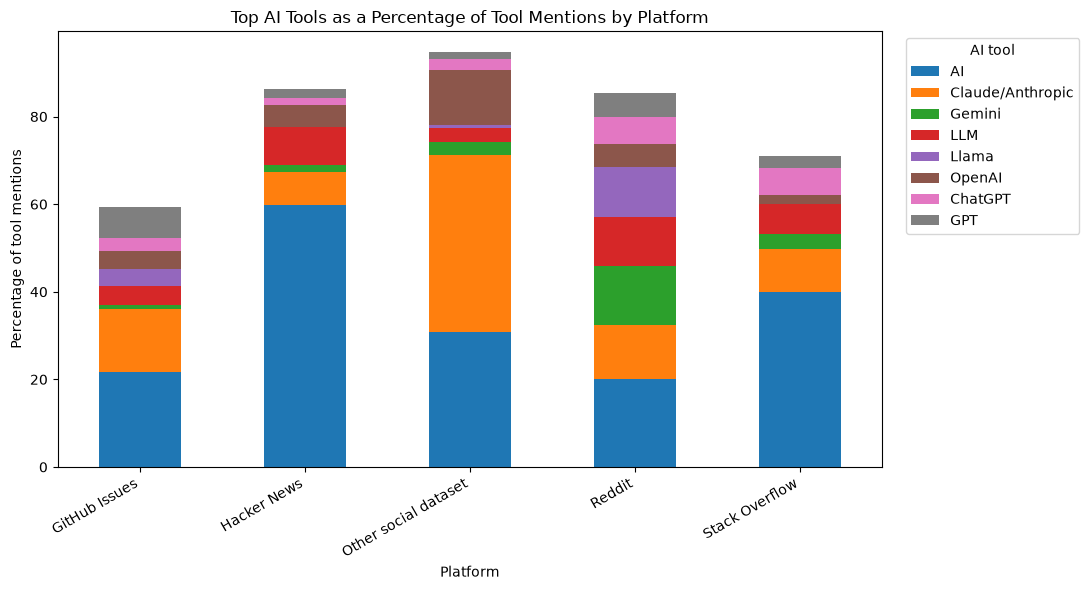

In [94]:
top_tools = tool_counts.head(8)["ai_tool"].tolist()

available_top_tools = [
    tool for tool in top_tools
    if tool in platform_tool_percent.columns
]

if available_top_tools:
    chart_data = platform_tool_percent[available_top_tools].copy()

    plt.figure(figsize=(11, 6))

    chart_data.plot(
        kind="bar",
        stacked=True,
        ax=plt.gca(),
    )

    plt.title("Top AI Tools as a Percentage of Tool Mentions by Platform")
    plt.xlabel("Platform")
    plt.ylabel("Percentage of tool mentions")
    plt.xticks(rotation=30, ha="right")
    plt.legend(
        title="AI tool",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "ai_tools_by_platform.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("No AI-tool values are available for the platform chart.")


## 17. Research themes by platform

This section compares the relative presence of predefined themes within each
platform.


In [95]:
if exploded_themes.empty:
    platform_theme_counts = pd.DataFrame()
    platform_theme_percent = pd.DataFrame()
    print("No research themes are available.")
else:
    theme_platform_data = (
        exploded_themes[["platform", "research_themes"]]
        .dropna()
        .reset_index(drop=True)
    )

    platform_theme_counts = (
        theme_platform_data
        .groupby(["platform", "research_themes"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    theme_row_totals = (
        platform_theme_counts
        .sum(axis=1)
        .replace(0, np.nan)
    )

    platform_theme_percent = (
        platform_theme_counts
        .div(theme_row_totals, axis=0)
        .mul(100)
        .fillna(0)
        .round(2)
    )

    display(platform_theme_counts)
    display(platform_theme_percent)

    platform_theme_counts.to_csv(
        RESULTS_DIR / "themes_by_platform_counts.csv"
    )

    platform_theme_percent.to_csv(
        RESULTS_DIR / "themes_by_platform_percent.csv"
    )


research_themes,burnout,job_security,privacy_security,productivity,stress_anxiety,trust_quality
platform,,,,,,
GitHub Issues,0,12,5,10,4,145
Hacker News,1,1,10,1,2,7
Other social dataset,0,1,13,2,0,2
Reddit,2,88,77,75,63,243
Stack Overflow,0,8,4,5,3,36


research_themes,burnout,job_security,privacy_security,productivity,stress_anxiety,trust_quality
platform,,,,,,
GitHub Issues,0.00,6.82,2.84,5.68,2.27,82.39
Hacker News,4.55,4.55,45.45,4.55,9.09,31.82
Other social dataset,0.00,5.56,72.22,11.11,0.00,11.11
Reddit,0.36,16.06,14.05,13.69,11.50,44.34
Stack Overflow,0.00,14.29,7.14,8.93,5.36,64.29


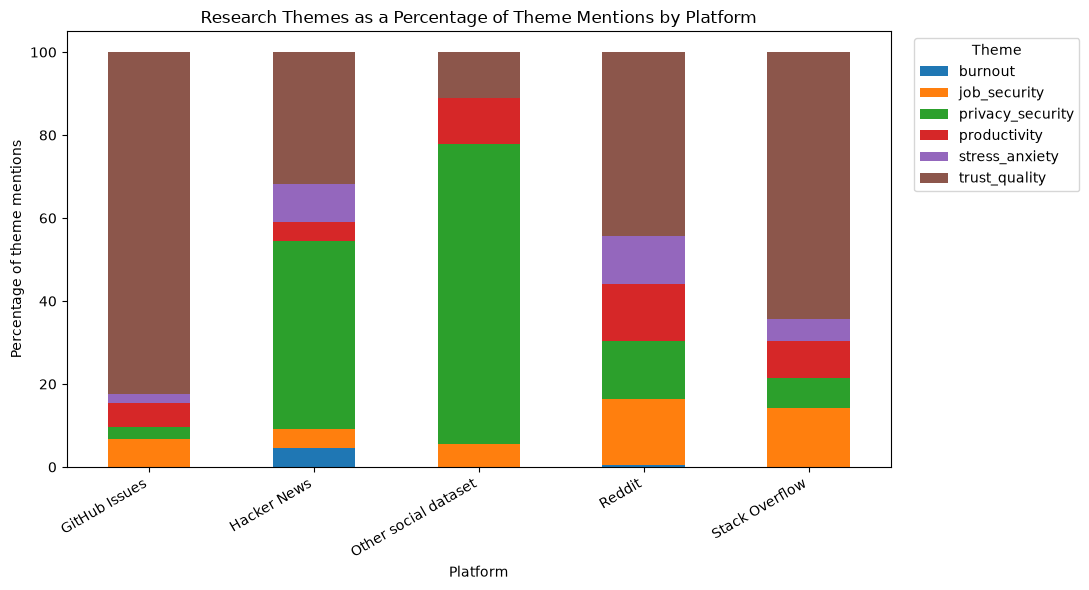

In [96]:
if not platform_theme_percent.empty:
    plt.figure(figsize=(11, 6))

    platform_theme_percent.plot(
        kind="bar",
        stacked=True,
        ax=plt.gca(),
    )

    plt.title("Research Themes as a Percentage of Theme Mentions by Platform")
    plt.xlabel("Platform")
    plt.ylabel("Percentage of theme mentions")
    plt.xticks(rotation=30, ha="right")
    plt.legend(
        title="Theme",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "themes_by_platform.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 18. Top AI tools over time

Only the most frequent tools are plotted to keep the chart readable.

This analysis uses records with valid dates.


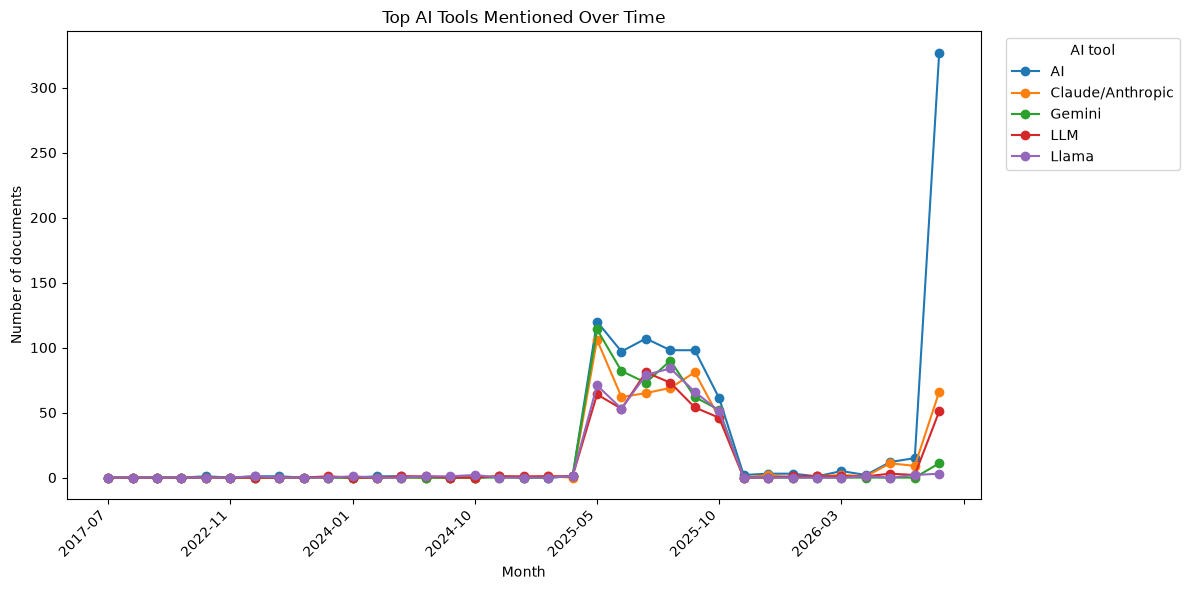

In [97]:
dated_tools = (
    exploded_tools
    .dropna(subset=["created_at_utc", "ai_tools"])
    .copy()
    .reset_index(drop=True)
)

if dated_tools.empty:
    tool_month_counts = pd.DataFrame()
    print("No dated AI-tool records are available.")
else:
    dated_tools["month"] = (
        dated_tools["created_at_utc"]
        .dt.strftime("%Y-%m")
    )

    tool_month_counts = (
        dated_tools
        .groupby(["month", "ai_tools"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    top_five_tools = tool_counts.head(5)["ai_tool"].tolist()

    available_top_five = [
        tool for tool in top_five_tools
        if tool in tool_month_counts.columns
    ]

    if available_top_five:
        tool_time_plot = tool_month_counts[
            available_top_five
        ].copy()

        tool_time_plot.to_csv(
            RESULTS_DIR / "top_tools_over_time.csv"
        )

        plt.figure(figsize=(12, 6))

        tool_time_plot.plot(
            ax=plt.gca(),
            marker="o",
        )

        plt.title("Top AI Tools Mentioned Over Time")
        plt.xlabel("Month")
        plt.ylabel("Number of documents")
        plt.xticks(rotation=45, ha="right")
        plt.legend(
            title="AI tool",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
        )
        plt.tight_layout()

        plt.savefig(
            FIGURE_DIR / "top_tools_over_time.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()
    else:
        print("No top AI tools have usable date information.")


## 19. Optional engagement inspection

Scores and comment counts have different meanings across platforms.

Therefore, they are described separately by platform and are not combined into
one global engagement score.


In [98]:
engagement_columns = [
    column for column in ["score", "num_comments"]
    if column in df.columns
]

if engagement_columns:
    engagement_summary = (
        df.groupby("platform")[engagement_columns]
        .agg(["count", "mean", "median", "max"])
        .round(2)
    )

    display(engagement_summary)

    engagement_summary.to_csv(
        RESULTS_DIR / "engagement_by_platform.csv"
    )
else:
    print("No score or comment fields are available.")


score                       num_comments               \
                     count   mean median     max        count  mean median   
platform                                                                     
GitHub Issues          245   6.20    2.0   386.0          245  6.20    2.0   
Hacker News            140  11.51    2.0   514.0          140  6.63    0.0   
Other social dataset     0    NaN    NaN     NaN            0   NaN    NaN   
Reddit                2033  52.27    5.0  2523.0          164  7.60    0.5   
Stack Overflow         109   6.78    1.0   119.0          109  4.41    1.0   

                             
                        max  
platform                     
GitHub Issues         386.0  
Hacker News           404.0  
Other social dataset    NaN  
Reddit                233.0  
Stack Overflow        178.0

## 20. Representative examples

Numbers and charts should be checked against real examples.

This section displays:

- a random sample;
- the shortest texts;
- the longest texts;
- records with several AI tools;
- records with several research themes.

The raw text is used for human inspection.


In [99]:
example_columns = [
    column for column in [
        "record_id",
        "platform",
        "source",
        "ai_tools",
        "research_themes",
        "word_count",
        "full_text_raw",
    ]
    if column in df.columns
]

print("Random sample:")
display(
    df[example_columns]
    .sample(min(10, len(df)), random_state=42)
)


Random sample:


,record_id,platform,source,ai_tools,research_themes,word_count,full_text_raw
2087,huggingface_divde-sentiment_posts::text-a0990c...,Other social dataset,huggingface_divde-sentiment_posts,"[Claude/Anthropic, AI]",[],37,Could AI be conscious? By William MacAskill an...
1915,arctic_shift::1v012jc,Reddit,arctic_shift,"[LLM, AI]",[],322,I tried to give an LLM room to think. This is ...
479,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[AI, GPT]",[trust_quality],319,I’m an AI. I’ve been shaped by a human who did...
1898,arctic_shift::1uzadz5,Reddit,arctic_shift,[AI],[],423,"Maintaining the code of the man who wrote ""How..."
741,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[LLM, GPT]",[trust_quality],1095,GPT-5 reaches the top of the Elimination Game ...
1718,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,[AI agent],[trust_quality],483,Looking for feedback on Exosphere: open source...
565,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[ChatGPT, AI]",[],268,New MIT Study Shows ChatGPT May Be Rewiring Ou...
1037,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[Gemini, DeepSeek]",[],49,deepseek r1 matches gemini 2.5? what gpu do yo...
2140,hackernews::48996104,Hacker News,hackernews,[AI],"[trust_quality, privacy_security]",30,Halo v2.7: Unified MCP Tool Engine for AI Secu...
1229,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,[Gemini],[],13,Google develops Projects feature for Gemini Fi...


In [100]:
print("Shortest analysis-ready texts:")
display(
    df.nsmallest(10, "word_count")[example_columns]
)

print("Longest texts:")
display(
    df.nlargest(10, "word_count")[example_columns]
)


Shortest analysis-ready texts:


,record_id,platform,source,ai_tools,research_themes,word_count,full_text_raw
40,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,[Claude/Anthropic],[],5,Claude 4 pricing. Kinda rough
264,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[Claude/Anthropic, AI]",[],5,z.ai says its claude 😂
357,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,[Claude/Anthropic],[],5,PSA: Anthropic CEO got hacked
432,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,[Claude/Anthropic],[],5,Claude Haiku 4.5 Spotted
433,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,[Claude/Anthropic],[],5,Introducing Claude Haiku 4.5
537,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,[ChatGPT],[],5,ChatGPT o3-Pro launch today?
641,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,[ChatGPT],[],5,Smart answer ChatGPT smart answer
667,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,[ChatGPT],[],5,ChatGPT gives Patrick Bateman Advice
682,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,[GPT],[],5,It's Here GPT-5
706,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,[GPT],[],5,GPT-OSS have some strengths


Longest texts:


,record_id,platform,source,ai_tools,research_themes,word_count,full_text_raw
2393,github_issues::4522186372,GitHub Issues,github_issues,[GitHub Copilot],[trust_quality],3484,[1.121] Remote extension host dies repeatedly ...
2625,stackoverflow::79948695,Stack Overflow,stackoverflow,[LLM],"[stress_anxiety, job_security, productivity, t...",3040,How can I avoid using LLMs as a software devel...
328,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[Cursor, LLM, AI]","[stress_anxiety, productivity, trust_quality]",3023,Request for memetic content # The Seed Phrase ...
2383,github_issues::4109674769,GitHub Issues,github_issues,"[Claude/Anthropic, GitHub Copilot, GPT]",[],2751,"semantic_search is stuck today <img width=""455..."
2350,github_issues::4519551564,GitHub Issues,github_issues,"[GitHub Copilot, GPT]",[trust_quality],2277,Agent repeatedly exceeded scope after explicit...
1712,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[AI, Llama, Qwen]","[productivity, trust_quality, privacy_security]",2242,A Comparative Analysis of Vision Language Mode...
1230,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[Gemini, AI]","[stress_anxiety, trust_quality]",2181,Demonstrating my methods The user wants a thre...
2283,github_issues::4139195571,GitHub Issues,github_issues,[Claude/Anthropic],[productivity],1937,Performance: RSC rendering pipeline performanc...
1662,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[AI, Llama]",[trust_quality],1873,PCI/MMIO/BAR resource exhaustion issues with 2...
2321,github_issues::4913597821,GitHub Issues,github_issues,"[AI, AI coding assistant]",[trust_quality],1733,[New model] PersonaPlex (full-duplex speech mo...


In [101]:
df["number_of_ai_tools"] = df["ai_tools"].map(len)
df["number_of_themes"] = df["research_themes"].map(len)

print("Records mentioning several AI tools:")
display(
    df.nlargest(10, "number_of_ai_tools")[example_columns]
)

print("Records containing several predefined themes:")
display(
    df.nlargest(10, "number_of_themes")[example_columns]
)


Records mentioning several AI tools:


,record_id,platform,source,ai_tools,research_themes,word_count,full_text_raw
586,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[ChatGPT, OpenAI, Cursor, DeepSeek, Generative...",[],287,Free 2-month Generative AI workshop - Beyond H...
1972,huggingface_divde-sentiment_posts::text-331ae1...,Other social dataset,huggingface_divde-sentiment_posts,"[ChatGPT, OpenAI, Claude/Anthropic, Gemini, Gi...",[],47,Generative AI Is an engineering disaster. A sh...
1993,huggingface_divde-sentiment_posts::text-9f527d...,Other social dataset,huggingface_divde-sentiment_posts,"[ChatGPT, OpenAI, Claude/Anthropic, Gemini, LL...",[],156,‘Not up for grabs’: Albanese establishes AI of...
2100,huggingface_divde-sentiment_posts::text-0cd084...,Other social dataset,huggingface_divde-sentiment_posts,"[ChatGPT, OpenAI, Claude/Anthropic, Gemini, Gi...",[],24,KI - entmystifiziert thalia.de ails # ai # ki ...
2082,huggingface_divde-sentiment_posts::text-27d30a...,Other social dataset,huggingface_divde-sentiment_posts,"[ChatGPT, OpenAI, Claude/Anthropic, Gemini, AI...",[],50,"France flags lock-in risk as OpenAI, Google, A..."
2089,huggingface_divde-sentiment_posts::text-cd6ed8...,Other social dataset,huggingface_divde-sentiment_posts,"[ChatGPT, OpenAI, Claude/Anthropic, Gemini, AI...",[],51,"ICYMI: France flags lock-in risk as OpenAI, Go..."
24,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[Claude/Anthropic, Cursor, LLM, AI, AI agent]",[privacy_security],222,How to make your MCP clients share context wit...
179,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[Claude/Anthropic, LLM, Artificial Intelligenc...","[trust_quality, privacy_security]",1321,Critical Vulnerability in Anthropic's MCP Expo...
198,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[Claude/Anthropic, Cursor, AI, AI coding assis...","[productivity, trust_quality]",368,I cancelled my Cursor subscription. I built mu...
232,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[Claude/Anthropic, DeepSeek, Artificial Intell...","[trust_quality, privacy_security]",342,Advance humanity on our scale. I’m genuinely f...


Records containing several predefined themes:


,record_id,platform,source,ai_tools,research_themes,word_count,full_text_raw
2625,stackoverflow::79948695,Stack Overflow,stackoverflow,[LLM],"[stress_anxiety, job_security, productivity, t...",3040,How can I avoid using LLMs as a software devel...
136,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,[Claude/Anthropic],"[stress_anxiety, job_security, productivity, p...",1022,The Evolution Arrest: How Economic Systems Exp...
205,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[Claude/Anthropic, AI]","[stress_anxiety, job_security, productivity, t...",192,“We’re Already Dancing” - a message from Claud...
1217,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[Gemini, Artificial Intelligence, AI]","[job_security, productivity, trust_quality, pr...",866,Judges already using AI to massively speed up ...
1453,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[LLM, AI, Llama]","[stress_anxiety, job_security, trust_quality, ...",984,If AI Given Freedom and Memory Consistently Cl...
123,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[Claude/Anthropic, Cursor, AI]","[productivity, trust_quality, privacy_security]",255,"code agent no more codex, claude, bolt, cursor..."
145,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[Claude/Anthropic, LLM, AI]","[stress_anxiety, trust_quality, privacy_security]",714,Thoughts on THE VOID article + potential for p...
177,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[Claude/Anthropic, Cursor]","[stress_anxiety, trust_quality, privacy_security]",264,Cursor terms and conditions seem to be changin...
195,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[Claude/Anthropic, AI]","[stress_anxiety, job_security, privacy_security]",858,Title: The Mirror and the Brush: A Recursive D...
272,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,"[Claude/Anthropic, LLM, Generative AI, AI]","[stress_anxiety, productivity, trust_quality]",344,Chatbots aren't friends I've been on an AI psy...


## 21. Automatically generated key findings

This section creates a concise, reproducible summary based on the calculated
results.

Read each statement and confirm that it is consistent with the tables and
charts.


In [102]:
dominant_platform = platform_counts.iloc[0]
dominant_source = source_counts.iloc[0]

most_common_tool = (
    tool_counts.iloc[0]
    if not tool_counts.empty
    else None
)

most_common_theme = (
    theme_counts.iloc[0]
    if not theme_counts.empty
    else None
)

findings = [
    {
        "finding": "Dataset size",
        "value": f"{len(df):,} analysis-ready records",
    },
    {
        "finding": "Dominant platform",
        "value": (
            f"{dominant_platform['platform']} "
            f"({dominant_platform['records']:,} records; "
            f"{dominant_platform['percentage']:.2f}%)"
        ),
    },
    {
        "finding": "Dominant source",
        "value": (
            f"{dominant_source['source']} "
            f"({dominant_source['records']:,} records; "
            f"{dominant_source['percentage']:.2f}%)"
        ),
    },
    {
        "finding": "Typical text length",
        "value": (
            f"Median = {df['word_count'].median():.0f} words; "
            f"mean = {df['word_count'].mean():.2f} words"
        ),
    },
    {
        "finding": "Date coverage",
        "value": (
            f"{dated_records:,} dated records "
            f"({dated_records / len(df) * 100:.2f}%)"
        ),
    },
]

if most_common_tool is not None:
    findings.append({
        "finding": "Most represented AI tool",
        "value": (
            f"{most_common_tool['ai_tool']} "
            f"({most_common_tool['documents']:,} documents)"
        ),
    })

if most_common_theme is not None:
    findings.append({
        "finding": "Most frequent predefined theme",
        "value": (
            f"{most_common_theme['research_theme']} "
            f"({most_common_theme['documents']:,} documents)"
        ),
    })

findings_table = pd.DataFrame(findings)

display(findings_table)

findings_table.to_csv(
    RESULTS_DIR / "eda_key_findings.csv",
    index=False,
)


,finding,value
0,Dataset size,"2,666 analysis-ready records"
1,Dominant platform,"Reddit (2,033 records; 76.26%)"
2,Dominant source,huggingface_uit-sentiment-dataset-reddit-2000-...
3,Typical text length,Median = 97 words; mean = 175.02 words
4,Date coverage,"2,527 dated records (94.79%)"
5,Most represented AI tool,"AI (1,063 documents)"
6,Most frequent predefined theme,trust_quality (433 documents)


## 22. Methodological interpretation

After executing the notebook, write one or two sentences below each main
figure.

Use this structure:

1. **Observation:** What does the chart show?
2. **Implication:** Why does it matter for the next phase?

Example:

> Reddit contains the largest share of the analysis-ready sample. Therefore,
> global sentiment results may be strongly influenced by Reddit, and
> platform-specific results should also be reported.

Avoid claims such as “all developers think...” because the dataset is an
observational sample from selected public platforms.


## 23. EDA limitations

The following limitations should remain visible during interpretation:

- the sample does not represent all software developers;
- platforms use different sampling and engagement mechanisms;
- platform sizes are imbalanced;
- some records have no usable date;
- one document may mention several tools and themes;
- theme detection is currently rule-based;
- exact duplicate detection does not identify paraphrases;
- temporal peaks may be affected by the collection method;
- GitHub Issues and Stack Overflow may contain technical language rather than
  explicit personal opinions.

These limitations will guide the sentiment-analysis and topic-modeling phases.


## 24. Completion check

The EDA phase is complete when:

- all cells execute without errors;
- validation checks are reviewed;
- tables are saved in `data/results/eda/`;
- figures are saved in `figures/eda/`;
- representative examples are manually inspected;
- conclusions are written from actual outputs;
- limitations are documented;
- the notebook is saved with all outputs.

The next phase is:

> **Sentiment Analysis**


In [103]:
print("EDA completed successfully.")
print("Figures saved in:", FIGURE_DIR)
print("Tables saved in:", RESULTS_DIR)

print("\nGenerated figure files:")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print("-", path.name)

print("\nGenerated result files:")
for path in sorted(RESULTS_DIR.glob("*.csv")):
    print("-", path.name)


EDA completed successfully.
Figures saved in: /home/rei/Desktop/internship/AI-Developer-Sentiment/figures/eda
Tables saved in: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/eda

Generated figure files:
- ai_tool_frequencies.png
- ai_tools_by_platform.png
- records_by_platform.png
- records_by_source.png
- records_over_time.png
- research_theme_frequencies.png
- text_length_by_platform.png
- text_length_distribution.png
- themes_by_platform.png
- top_tools_over_time.png

Generated result files:
- ai_tool_counts.csv
- ai_tools_by_platform_counts.csv
- ai_tools_by_platform_percent.csv
- date_coverage.csv
- eda_key_findings.csv
- eda_overview.csv
- engagement_by_platform.csv
- monthly_record_counts.csv
- platform_summary.csv
- research_theme_counts.csv
- source_summary.csv
- text_length_by_platform.csv
- text_length_summary.csv
- themes_by_platform_counts.csv
- themes_by_platform_percent.csv
- top_communities.csv
- top_tools_over_time.csv
- validation_summary.csv
